Import Packages

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.dates as mdates
import plotly.express as px, plotly.graph_objects as go
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
##Read Covid  data
covid_url = "https://data.cityofnewyork.us/resource/rc75-m7u3.csv"

df_covid = pd.read_csv(covid_url)
df_covid.columns = df_covid.columns.str.lower().str.strip()
df_covid["date_of_interest"] = pd.to_datetime(df_covid["date_of_interest"])

In [ ]:
##choosing start date
start_date = pd.to_datetime("2020-03-07")
df_covid = df_covid[df_covid["date_of_interest"] >= start_date]

In [ ]:
##Read ir Quality data
df_air = pd.read_csv("https://data.cityofnewyork.us/resource/c3uy-2p5r.csv")
df_air.columns = df_air.columns.str.lower().str.strip()
df_air["start_date"] = pd.to_datetime(df_air["start_date"])
###Choosing start date
start_date = pd.to_datetime("2020-03-07")
df_air = df_air[df_air["start_date"] >= start_date]
df_air["borough"] = df_air["geo_place_name"].str.lower()

In [ ]:
###convert covid data from long to wide:
df_covid["date_of_interest"] = pd.to_datetime(df_covid["date_of_interest"])

covid_long = df_covid.melt(
    id_vars=["date_of_interest"],
    value_vars=[
        "bx_case_count",
        "bk_case_count",
        "mn_case_count",
        "qn_case_count",
        "si_case_count"
    ],
    var_name="borough",
    value_name="cases"
)
covid_long.columns

Index(['date_of_interest', 'borough', 'cases'], dtype='object')

In [ ]:

##Clean borough name
covid_long["borough"] = covid_long["borough"].str.replace("_case_count", "", regex=False)
covid_long["borough"] = covid_long["borough"].str.lower()
df_covid.columns

Index(['date_of_interest', 'case_count', 'probable_case_count',
       'hospitalized_count', 'death_count', 'case_count_7day_avg',
       'all_case_count_7day_avg', 'hosp_count_7day_avg',
       'death_count_7day_avg', 'bx_case_count', 'bx_probable_case_count',
       'bx_hospitalized_count', 'bx_death_count', 'bx_case_count_7day_avg',
       'bx_probable_case_count_7day_avg', 'bx_all_case_count_7day_avg',
       'bx_hospitalized_count_7day_avg', 'bx_death_count_7day_avg',
       'bk_case_count', 'bk_probable_case_count', 'bk_hospitalized_count',
       'bk_death_count', 'bk_case_count_7day_avg',
       'bk_probable_case_count_7day_avg', 'bk_all_case_count_7day_avg',
       'bk_hospitalized_count_7day_avg', 'bk_death_count_7day_avg',
       'mn_case_count', 'mn_probable_case_count', 'mn_hospitalized_count',
       'mn_death_count', 'mn_case_count_7day_avg',
       'mn_probable_case_count_7day_avg', 'mn_all_case_count_7day_avg',
       'mn_hospitalized_count_7day_avg', 'mn_death_count_7

In [ ]:
##Merge data
merged = pd.merge(
    covid_long,
    df_air,
    left_on=["date_of_interest"],
    right_on=["start_date"],
    how="inner"
)

merged = merged.drop(columns=["start_date"])
merged.head()


,date_of_interest,borough_x,cases,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,data_value,message,borough_y
0,2022-06-01,bx,502,827145,386,Ozone (O3),Mean,ppb,Borough,4,Queens,Summer 2022,34.457064,NaN,queens
1,2022-06-01,bx,502,827032,386,Ozone (O3),Mean,ppb,CD,205,Fordham and University Heights (CD5),Summer 2022,31.197251,NaN,fordham and university heights (cd5)
2,2022-06-01,bx,502,823349,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,101,Financial District (CD1),Summer 2022,7.442511,NaN,financial district (cd1)
3,2022-06-01,bx,502,823158,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,202,Hunts Point and Longwood (CD2),Summer 2022,7.453216,NaN,hunts point and longwood (cd2)
4,2022-06-01,bx,502,827062,386,Ozone (O3),Mean,ppb,UHF34,403,Flushing - Clearview,Summer 2022,34.484806,NaN,flushing - clearview


In [ ]:
print(merged["borough_x"].unique())
print(merged["borough_y"].unique())

['bx' 'bk' 'mn' 'qn' 'si']
['queens' 'fordham and university heights (cd5)'
 'financial district (cd1)' 'hunts point and longwood (cd2)'
 'flushing - clearview' 'port richmond' 'fresh meadows' 'southwest queens'
 'greenpoint' 'east harlem' 'sunset park (cd7)'
 'central harlem - morningside heights']


In [ ]:
###3 since borough x and borough y does not correspong in the merge, i will remerged it but mapping borough x to the corresponding borough y

In [ ]:
mapping = {
    "bk_case_count": ["east new york", "greenpoint", "east flatbush - flatbush"],
    "bx_case_count": ["fordham and university heights (cd5)", "east harlem", "hunts point and longwood (cd2)"],
    "qn_case_count": ["queens", "fresh meadows", "west queens", "flushing - clearview"],
    "si_case_count": ["port richmond"],
    "mn_case_count": ["financial district (cd1)"]
}

#CLEAN All DATASET BOROUGH NAME
df_air["geo_place_name"] = df_air["geo_place_name"].str.lower()

In [ ]:
##convert wide COVID columns into mapped row
covid_long = df_covid.melt(
    id_vars=["date_of_interest"],
    value_vars=list(mapping.keys()),
    var_name="case_type",
    value_name="cases"
)

covid_long["geo_place_name"] = covid_long["case_type"].map(
    lambda x: mapping[x]
)
covid_long = covid_long.explode("geo_place_name")
covid_long["geo_place_name"] = covid_long["geo_place_name"].str.lower()

In [ ]:
##REMERGED AGAIN THE DATA
merged2 = pd.merge(
    covid_long,
    df_air,
    left_on=["date_of_interest", "geo_place_name"],
    right_on=["start_date", "geo_place_name"],
    how="inner"
)
merged2 = merged2.drop(columns=["start_date"])
merged2.head()

,date_of_interest,case_type,cases,geo_place_name,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,time_period,data_value,message,borough
0,2022-06-01,bk_case_count,1115,greenpoint,825775,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,201,Summer 2022,14.068715,NaN,greenpoint
1,2022-06-01,bx_case_count,502,fordham and university heights (cd5),827032,386,Ozone (O3),Mean,ppb,CD,205,Summer 2022,31.197251,NaN,fordham and university heights (cd5)
2,2022-06-01,bx_case_count,502,east harlem,825736,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,303,Summer 2022,12.958281,NaN,east harlem
3,2022-06-01,bx_case_count,502,hunts point and longwood (cd2),823158,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,202,Summer 2022,7.453216,NaN,hunts point and longwood (cd2)
4,2022-06-01,bx_case_count,502,hunts point and longwood (cd2),826001,375,Nitrogen dioxide (NO2),Mean,ppb,CD,202,Summer 2022,14.157573,NaN,hunts point and longwood (cd2)


In [ ]:
merged2.columns

Index(['date_of_interest', 'case_type', 'cases', 'geo_place_name', 'unique_id',
       'indicator_id', 'name', 'measure', 'measure_info', 'geo_type_name',
       'geo_join_id', 'time_period', 'data_value', 'message', 'borough'],
      dtype='object')

In [ ]:
###convert covid data from long to wide:
df_covid["date_of_interest"] = pd.to_datetime(df_covid["date_of_interest"])

covid_long = df_covid.melt(
    id_vars=["date_of_interest"],
    value_vars=[
        "bx_case_count",
        "bk_case_count",
        "mn_case_count",
        "qn_case_count",
        "si_case_count"
    ],
    var_name="borough",
    value_name="cases"
)
covid_long.columns



Index(['date_of_interest', 'borough', 'cases'], dtype='object')

In [ ]:

##Clean borough name
covid_long["borough"] = covid_long["borough"].str.replace("_case_count", "", regex=False)
covid_long["borough"] = covid_long["borough"].str.lower()
df_covid.columns

Index(['date_of_interest', 'case_count', 'probable_case_count',
       'hospitalized_count', 'death_count', 'case_count_7day_avg',
       'all_case_count_7day_avg', 'hosp_count_7day_avg',
       'death_count_7day_avg', 'bx_case_count', 'bx_probable_case_count',
       'bx_hospitalized_count', 'bx_death_count', 'bx_case_count_7day_avg',
       'bx_probable_case_count_7day_avg', 'bx_all_case_count_7day_avg',
       'bx_hospitalized_count_7day_avg', 'bx_death_count_7day_avg',
       'bk_case_count', 'bk_probable_case_count', 'bk_hospitalized_count',
       'bk_death_count', 'bk_case_count_7day_avg',
       'bk_probable_case_count_7day_avg', 'bk_all_case_count_7day_avg',
       'bk_hospitalized_count_7day_avg', 'bk_death_count_7day_avg',
       'mn_case_count', 'mn_probable_case_count', 'mn_hospitalized_count',
       'mn_death_count', 'mn_case_count_7day_avg',
       'mn_probable_case_count_7day_avg', 'mn_all_case_count_7day_avg',
       'mn_hospitalized_count_7day_avg', 'mn_death_count_7

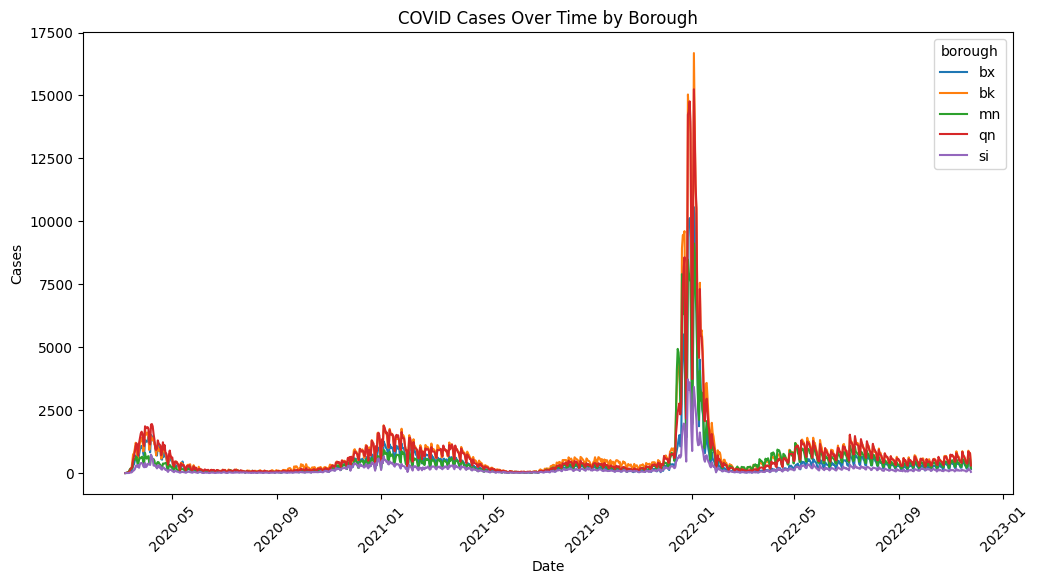

In [ ]:
##Covid cases overtime by borough


plt.figure(figsize=(12,6))

sns.lineplot(
    data=covid_long,
    x="date_of_interest",
    y="cases",
    hue="borough"
)

plt.title("COVID Cases Over Time by Borough")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.xticks(rotation=45)

plt.show()

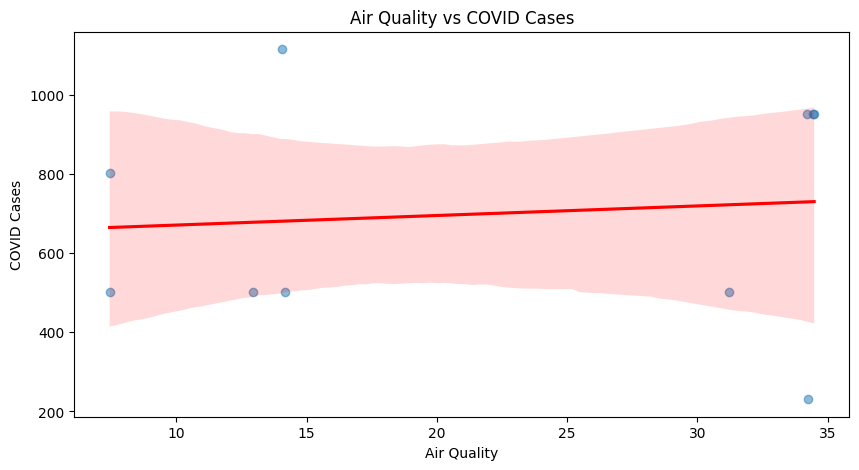

In [ ]:
##Does air quality affects covid cases

plt.figure(figsize=(10,5))

sns.regplot(
    data=merged2,
    x="data_value",
    y="cases",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Air Quality vs COVID Cases")
plt.xlabel("Air Quality")
plt.ylabel("COVID Cases")

plt.show()

There’s no clear correlation between air quality and covid cases

/tmp/ipykernel_12426/2036990636.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Brooklyn","Bronx","Queens","Staten Island","Manhattan"], rotation=45)
/tmp/ipykernel_12426/2036990636.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Brooklyn","Bronx","Queens","Staten Island","Manhattan"], rotation=45)


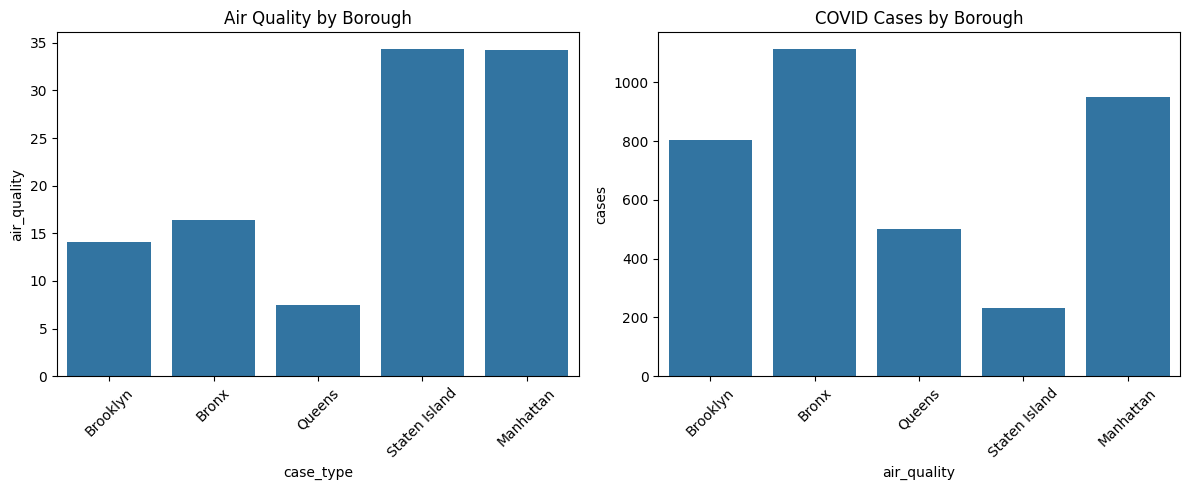

In [ ]:
##Air quality and Covid cases by borough
merged2 = merged2.rename(columns={"data_value": "air_quality"})

summary = merged2.groupby("case_type")[["air_quality", "cases"]].mean().reset_index()

# Step 2: plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Air Quality
sns.barplot(data=summary, x="case_type", y="air_quality", ax=axes[0])
axes[0].set_title("Air Quality by Borough")
axes[0].set_xticklabels(["Brooklyn","Bronx","Queens","Staten Island","Manhattan"], rotation=45)

# COVID Cases
sns.barplot(data=summary, x="air_quality", y="cases", ax=axes[1])
axes[1].set_title("COVID Cases by Borough")
axes[1].set_xticklabels(["Brooklyn","Bronx","Queens","Staten Island","Manhattan"], rotation=45)

plt.tight_layout()
plt.show()

There is not a positive correlation between worse air quality and higher COVID-19 cases in this data.

For example, Manhattan has high air pollution but the lowest case count.
Brooklyn has moderate air pollution but the highest case count.

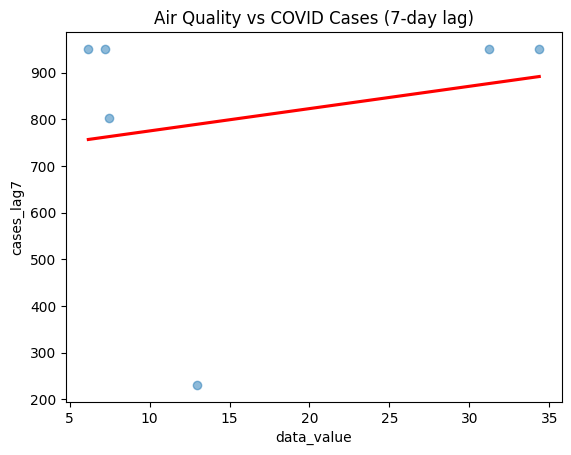

In [ ]:
###Do higher pollution levels today relate to more COVID cases a week later?

df = merged2.sort_values("date_of_interest")

df["cases_lag7"] = df["cases"].shift(-7)

# remove missing values
df = df.dropna(subset=["cases_lag7", "data_value"])

sns.regplot(
    data=df,
    x="data_value",
    y="cases_lag7",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
    ci=None  # removes that huge shaded triangle
)

plt.title("Air Quality vs COVID Cases (7-day lag)")
plt.show()

showing positive trend, bu t not enough point to be reliable


Mean cases by pollution group:
pollution_group
High Pollution    807.428571
Low Pollution     756.500000
Name: cases, dtype: float64


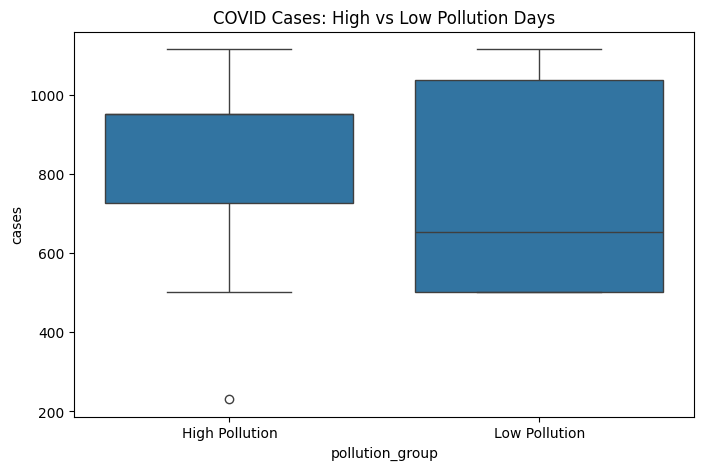

In [ ]:
# Covid Cases at high pollution vs low pollution days

df = merged2.copy()
df["date_of_interest"] = pd.to_datetime(df["date_of_interest"])
df = df.dropna(subset=["cases", "data_value", "borough"])


# 2. Summary stats by pollution level

threshold = df["data_value"].median()

df["pollution_group"] = df["data_value"].apply(
    lambda x: "High Pollution" if x >= threshold else "Low Pollution"
)

print("\nMean cases by pollution group:")
print(df.groupby("pollution_group")["cases"].mean())


plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="pollution_group", y="cases")
plt.title("COVID Cases: High vs Low Pollution Days")
plt.show()



In [ ]:
###COVID case counts are slightly higher on high pollution days on average, but the distributions overlap substantially, suggesting that pollution alone is not a strong predictor of case variation in this dataset

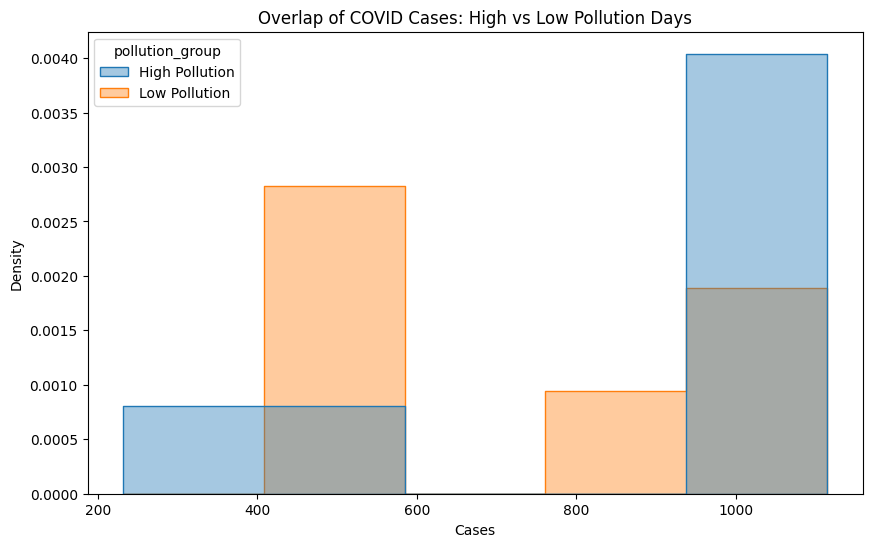

In [ ]:
##Plotting overlap in histogram
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="cases",
    hue="pollution_group",
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title("Overlap of COVID Cases: High vs Low Pollution Days")
plt.xlabel("Cases")
plt.ylabel("Density")
plt.show()

COVID case counts are influenced by many other stronger factors, such as:
Time trends (waves of infection)
Policy changes (lockdowns, mask rules)
Testing availability
Population density differences by borough
Seasonal effects (winter vs summer

In [ ]:
borough_map = {
    "bx": "Bronx",
    "bk": "Brooklyn",
    "mn": "Manhattan",
    "qn": "Queens",
    "si": "Staten Island"
}

borough_data = []

for code, name in borough_map.items():
    cases_col = f"{code}_case_count"
    death_col = f"{code}_death_count"

    borough_data.append({
        "borough": name,
        "cases": df_covid[cases_col].sum(),
        "deaths": df_covid[death_col].sum()
    })

borough_df = pd.DataFrame(borough_data)

In [ ]:
##Map of covid cases

import plotly.express as px

fig = px.choropleth(
    borough_df,
    geojson="https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/new-york-city-boroughs.geojson",
    featureidkey="properties.name",
    locations="borough",
    color="cases",
    color_continuous_scale="Reds",
    title="NYC COVID Cases by Borough"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [ ]:
###Map of covid deathe by borough
fig = px.choropleth(
    borough_df,
    geojson="https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/new-york-city-boroughs.geojson",
    featureidkey="properties.name",
    locations="borough",
    color="deaths",
    color_continuous_scale="Blues",
    title="NYC COVID Deaths by Borough"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [ ]:
url = "https://data.cityofnewyork.us/resource/pri4-ifjk.csv"
zcta_df = pd.read_csv(url)
zcta["borough"] = "Unknown"

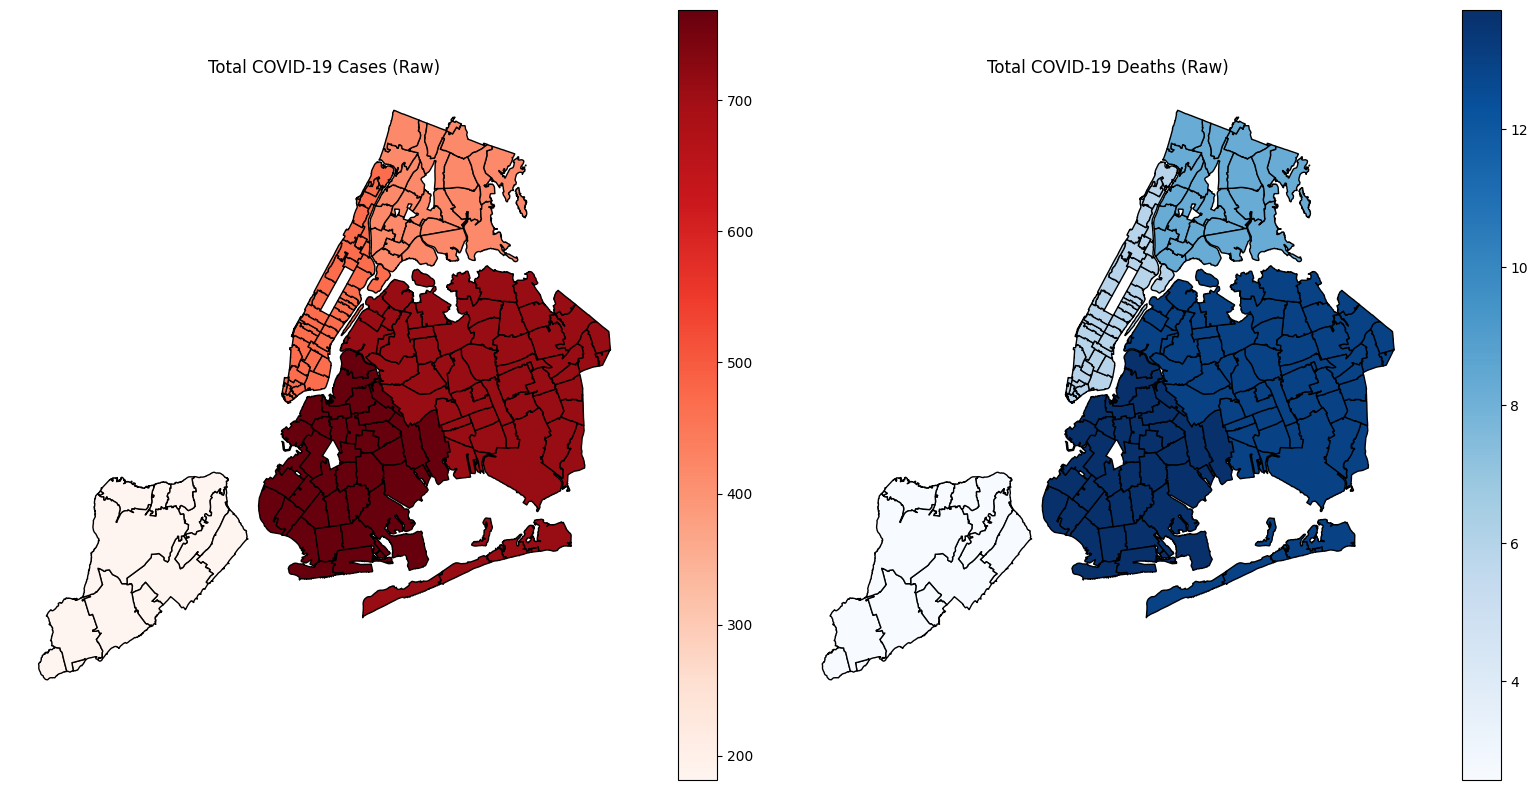

In [ ]:
borough_data = pd.DataFrame({
    "borough": ["Bronx","Brooklyn","Manhattan","Queens","Staten Island"],
    "case_count": [
        df_covid["bx_case_count"].mean(),
        df_covid["bk_case_count"].mean(),
        df_covid["mn_case_count"].mean(),
        df_covid["qn_case_count"].mean(),
        df_covid["si_case_count"].mean()
    ],
    "death_count": [
        df_covid["bx_death_count"].mean(),
        df_covid["bk_death_count"].mean(),
        df_covid["mn_death_count"].mean(),
        df_covid["qn_death_count"].mean(),
        df_covid["si_death_count"].mean()
    ]
})

# -----------------------
# 3. LOAD MODZCTA MAP
# -----------------------
zcta = gpd.read_file("https://data.cityofnewyork.us/resource/pri4-ifjk.geojson")
zcta.columns = zcta.columns.str.lower()

# -----------------------
# 4. BOROUGH ASSIGNMENT (APPROX)
# -----------------------
def assign_borough(z):
    z = int(z)
    if 10400 <= z <= 10499:
        return "Bronx"
    elif 11200 <= z <= 11299:
        return "Brooklyn"
    elif 10000 <= z <= 10299:
        return "Manhattan"
    elif 11000 <= z <= 11699:
        return "Queens"
    elif 10300 <= z <= 10399:
        return "Staten Island"
    return "Unknown"

zcta["borough"] = zcta["modzcta"].apply(assign_borough)

# -----------------------
# 5. MERGE
# -----------------------
merged = zcta.merge(borough_data, on="borough", how="left")

# -----------------------
# 6. PLOT RAW VALUES
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

merged.plot(
    column="case_count",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax[0]
)
ax[0].set_title("Total COVID-19 Cases (Raw)")
ax[0].axis("off")

merged.plot(
    column="death_count",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax[1]
)
ax[1].set_title("Total COVID-19 Deaths (Raw)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -----------------------
# 1. LOAD ZIP GEOMETRY
# -----------------------
zcta = gpd.read_file("https://data.cityofnewyork.us/resource/pri4-ifjk.geojson")
zcta.columns = zcta.columns.str.lower()
zcta["modzcta"] = zcta["modzcta"].astype(str)

# -----------------------
# 2. LOAD COVID DATA (CORRECT SOURCE)
# -----------------------
covid_url = "https://data.cityofnewyork.us/resource/pri4-ifjk.json?$limit=500000"
df = pd.read_json(covid_url)

df.columns = df.columns.str.lower().str.strip()

# keep only what exists
print("Columns:", df.columns)

# -----------------------
# 3. CHECK IF DATA EXISTS
# -----------------------
# Some versions already come aggregated by ZIP
if "case_count" in df.columns and "death_count" in df.columns:

    df["modzcta"] = df["modzcta"].astype(str)

    zip_data = df.groupby("modzcta")[["case_count", "death_count"]].mean().reset_index()

else:
    raise ValueError("This dataset version does not include case/death counts.")

# -----------------------
# 4. MERGE
# -----------------------
merged = zcta.merge(zip_data, on="modzcta", how="left")

merged = merged.dropna(subset=["case_count", "death_count"])

# -----------------------
# 5. PLOT
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

merged.plot(column="case_count", cmap="Reds", legend=True, ax=ax[0], edgecolor="black")
ax[0].set_title("COVID Cases by ZIP")
ax[0].axis("off")

merged.plot(column="death_count", cmap="Blues", legend=True, ax=ax[1], edgecolor="black")
ax[1].set_title("COVID Deaths by ZIP")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Columns: Index(['modzcta', 'label', 'zcta', 'pop_est', 'the_geom'], dtype='object')


ValueError: This dataset version does not include case/death counts.